Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data: 590
Rows with both Rs and J0 maps existing: 274
Rows removed due to missing physics maps: 316

Total valid samples: 274

Sample rows:
                                             rs_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 219
Val samples:   27
Test samp

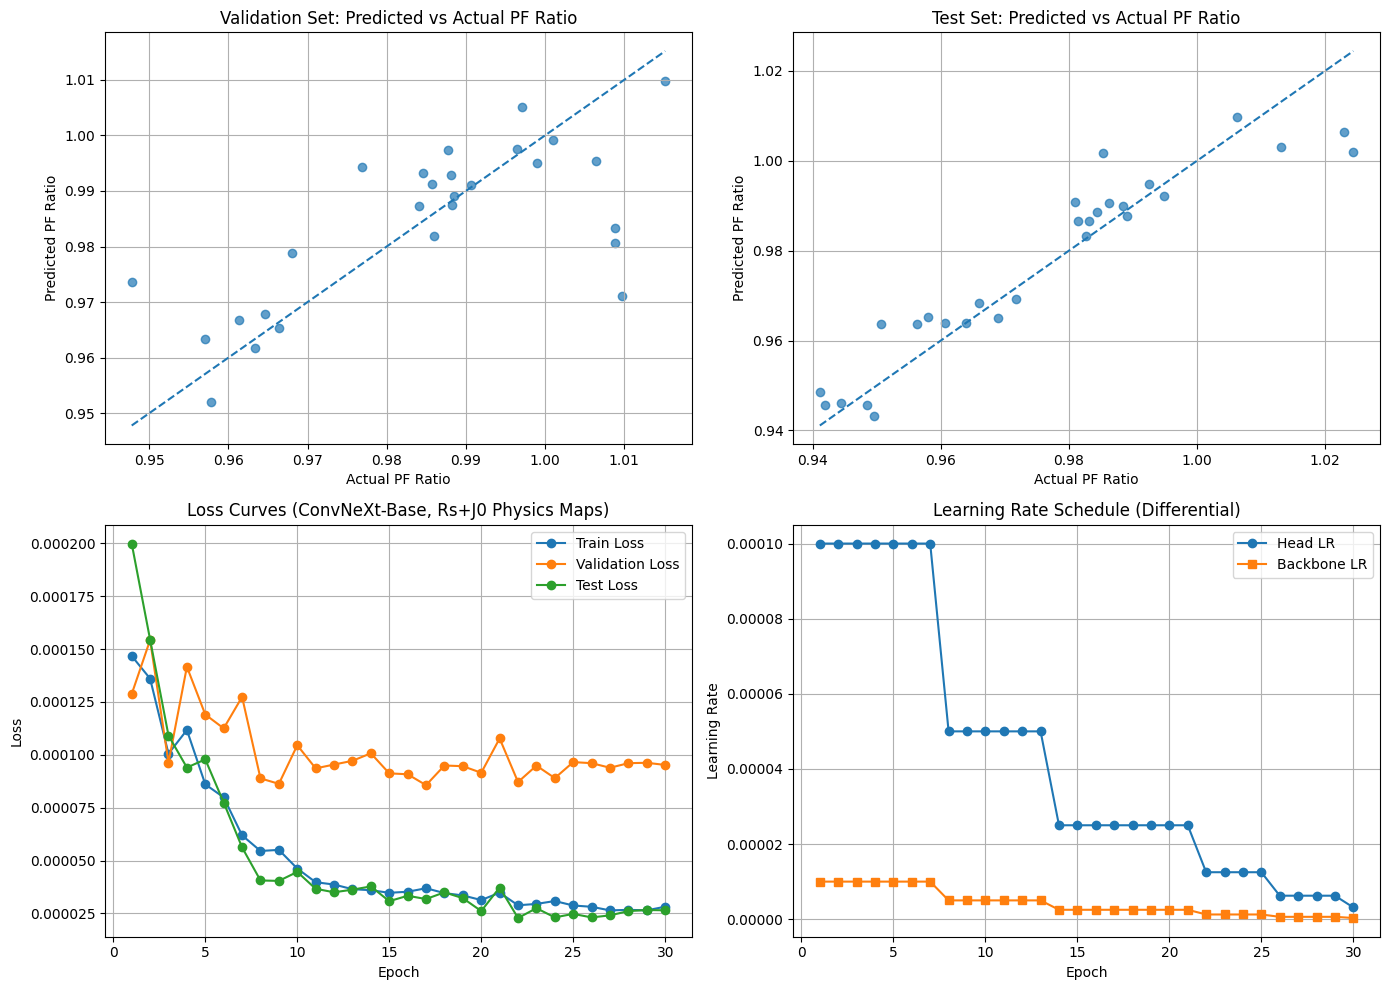


Saved:
- results_convnext_physics_RsJ0.png
- validation_predictions_physics_RsJ0.csv
- test_predictions_physics_RsJ0.csv

Model saved to: convnext_base_physics_RsJ0_best_val_model.pth


In [1]:
import os
import math
import copy
import random
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# Folder containing the Rs and J0 maps (relative to CSV directory)
PHYSICS_MAP_DIR = "J0_Rs"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def derive_physics_paths(elh_path_str, base_dir):
    """
    Derive Rs and J0 map paths from the ELHPath column.

    ELHPath:  ./EL/3883_35_1_01272020_80.tiff
    Rs path:  ./J0_Rs/3883_35_1_01272020_Rs.tiff
    J0 path:  ./J0_Rs/3883_35_1_01272020_J0.tiff

    Steps:
    1. Extract filename, strip bias suffix (e.g. _80)
    2. Append _Rs / _J0 and place in PHYSICS_MAP_DIR folder
    """
    if pd.isna(elh_path_str):
        return None, None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None, None

    filename = os.path.basename(elh_path_str)       # 3883_35_1_01272020_80.tiff
    name, ext = os.path.splitext(filename)           # 3883_35_1_01272020_80, .tiff

    # Remove the last underscore-separated segment (bias value like _80 or _20)
    base_name = name.rsplit("_", 1)[0]               # 3883_35_1_01272020

    rs_filename = f"{base_name}_Rs{ext}"
    j0_filename = f"{base_name}_J0{ext}"

    rs_path = os.path.normpath(os.path.join(base_dir, PHYSICS_MAP_DIR, rs_filename))
    j0_path = os.path.normpath(os.path.join(base_dir, PHYSICS_MAP_DIR, j0_filename))

    return rs_path, j0_path


def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]
    df = df[df["Pmp_(W)"].notna()]

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Derive Rs and J0 paths from ELHPath
    paths = df["ELHPath"].apply(lambda p: derive_physics_paths(p, base_dir))
    df["rs_path"] = paths.apply(lambda x: x[0])
    df["j0_path"] = paths.apply(lambda x: x[1])

    # Remove rows where paths could not be derived
    df = df[df["rs_path"].notna() & df["j0_path"].notna()]

    # Keep only rows whose physics map files actually exist
    df["rs_exists"] = df["rs_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["rs_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data: {total_before}")
    print(f"Rows with both Rs and J0 maps existing: {total_after}")
    print(f"Rows removed due to missing physics maps: {total_before - total_after}")

    keep_cols = ["rs_path", "j0_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET (2-channel: Rs + J0 physics maps)
# =========================================================
class PhysicsMapDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = None

        if preload:
            self._preload_all()

    def _preload_all(self):
        """
        Read, resize, and cache all Rs/J0 maps as float32.
        Physics maps are floating-point (not uint8), so we store as float32.
        For 400 samples at 224x224 float32: ~400 * 2 * 224 * 224 * 4 bytes ≈ 153 MB
        """
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size * 4 / (1024 ** 2)
        print(f"\n  Preloading {n} samples ({n * 2} physics maps) into RAM...")
        print(f"  Expected memory: ~{expected_mb:.0f} MB")
        t0 = time.time()

        self.cache_rs = np.empty((n, self.image_size, self.image_size), dtype=np.float32)
        self.cache_j0 = np.empty((n, self.image_size, self.image_size), dtype=np.float32)

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                rs_raw = self.read_physics_map(row["rs_path"])
                j0_raw = self.read_physics_map(row["j0_path"])
                self.cache_rs[i] = self.resize_image(rs_raw)
                self.cache_j0[i] = self.resize_image(j0_raw)
            except Exception as e:
                print(f"    Warning: failed to load sample {i}: {e}")
                self.cache_rs[i] = 0
                self.cache_j0[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_rs.nbytes + self.cache_j0.nbytes) / (1024 ** 2)
        print(f"  Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}")

        self.cache = True

    def read_physics_map(self, path):
        """
        Read a physics-derived map (Rs or J0) as float.
        These are floating-point TIFFs, not 8-bit grayscale.
        """
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise ValueError(f"Failed to load physics map: {path}")

        # If multi-channel, take first channel
        if img.ndim == 3:
            img = img[:, :, 0]

        # Convert to float32 and handle invalid values
        img = img.astype(np.float32)
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def normalize_map(self, img):
        """
        Per-sample min-max normalization to [0, 1].
        Preserves spatial patterns (which cells have high/low values)
        while scaling to a range suitable for CNN input.
        """
        vmin = img.min()
        vmax = img.max()
        if vmax - vmin > 1e-8:
            return (img - vmin) / (vmax - vmin)
        else:
            return np.zeros_like(img)

    def apply_same_augmentation(self, rs_img, j0_img):
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 1)
            j0_img = cv2.flip(j0_img, 1)
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 0)
            j0_img = cv2.flip(j0_img, 0)
        return rs_img, j0_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            rs_img = self.cache_rs[idx].copy()
            j0_img = self.cache_j0[idx].copy()
        else:
            rs_img = self.resize_image(self.read_physics_map(row["rs_path"]))
            j0_img = self.resize_image(self.read_physics_map(row["j0_path"]))

        if self.augment:
            rs_img, j0_img = self.apply_same_augmentation(rs_img, j0_img)

        # Normalize each map independently to [0, 1]
        rs_img = self.normalize_map(rs_img)
        j0_img = self.normalize_map(j0_img)

        # [H, W] -> [1, H, W] each, then stack -> [2, H, W]
        rs_img = np.expand_dims(rs_img, axis=0)
        j0_img = np.expand_dims(j0_img, axis=0)
        x = np.concatenate([rs_img, j0_img], axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y


class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


# =========================================================
# MODEL (2-channel: Rs + J0)
# =========================================================
def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified to accept 2-channel input (Rs + J0 maps)
    and output 1 regression value.
    """
    if pretrained:
        weights = models.ConvNeXt_Base_Weights.DEFAULT
    else:
        weights = None

    model = models.convnext_base(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None)
    )

    with torch.no_grad():
        if pretrained:
            old_weights = old_conv.weight
            new_conv.weight[:, 0, :, :] = old_weights[:, 0, :, :]
            new_conv.weight[:, 1, :, :] = old_weights[:, 1, :, :]
            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features[0][0] = new_conv

    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# PLOTTING
# =========================================================
def plot_scatter(ax, trues, preds, title):
    ax.scatter(trues, preds, alpha=0.7)
    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print(f"\nTotal valid samples: {len(df)}")
    print("\nSample rows:")
    print(df.head())

    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED)

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = PhysicsMapDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = PhysicsMapDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = PhysicsMapDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": LEARNING_RATE},
    ], weight_decay=1e-2)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    train_losses = []
    val_losses = []
    test_losses = []
    learning_rates = []
    backbone_lrs = []

    print(f"\n{'='*70}")
    print("Starting training (ConvNeXt-Base, UNFROZEN, 2ch Rs+J0 physics maps)...")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'='*70}\n")
    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()
        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]
        backbone_lrs.append(current_backbone_lr)
        learning_rates.append(current_head_lr)

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time/60:.1f} min)")

    # -------------------------
    # Final evaluation
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print("\nBest Model Performance (selected by Validation RMSE)")
    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    # -------------------------
    # Plotting
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_scatter(
        axes[0, 0], val_trues, val_preds,
        "Validation Set: Predicted vs Actual PF Ratio"
    )
    plot_scatter(
        axes[0, 1], test_trues, test_preds,
        "Test Set: Predicted vs Actual PF Ratio"
    )

    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), test_losses, label="Test Loss", marker="o")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curves (ConvNeXt-Base, Rs+J0 Physics Maps)")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(range(1, NUM_EPOCHS + 1), learning_rates, marker="o", label="Head LR")
    axes[1, 1].plot(range(1, NUM_EPOCHS + 1), backbone_lrs, marker="s", label="Backbone LR")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule (Differential)")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("results_convnext_physics_RsJ0.png", dpi=300, bbox_inches="tight")
    plt.show()

    val_results_df = pd.DataFrame({
        "actual_pf_ratio": val_trues,
        "predicted_pf_ratio": val_preds
    })
    val_results_df.to_csv("validation_predictions_physics_RsJ0.csv", index=False)

    test_results_df = pd.DataFrame({
        "actual_pf_ratio": test_trues,
        "predicted_pf_ratio": test_preds
    })
    test_results_df.to_csv("test_predictions_physics_RsJ0.csv", index=False)

    print("\nSaved:")
    print("- results_convnext_physics_RsJ0.png")
    print("- validation_predictions_physics_RsJ0.csv")
    print("- test_predictions_physics_RsJ0.csv")

    save_path = "convnext_base_physics_RsJ0_best_val_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()